# Methods Tutorial: Audio Transcription with Whisper

## Introduction

This tutorial teaches how OpenAI's **Whisper large-v3-turbo** model takes an audio waveform as input and produces a text transcription as output.

We walk through the complete inference pipeline using the real model — from loading the weights, preprocessing audio into mel-spectrogram features, generating tokens, to decoding the final text. The model is ~809 M parameters (~1.6 GB download) and runs on both CPU and GPU.

Everything you need is contained in this notebook. You do not need any external project files.

### What You'll Learn

By the end of this tutorial, you will understand:

- The three components of a speech model: **model**, **processor**, and **tokenizer**
- How Whisper converts audio into a **mel spectrogram** before feeding it to the encoder
- What **Whisper large-v3-turbo** adds: multilingual ASR, translation, timestamps, batching, and long-form audio handling
- How the **processor** extracts audio features and prepares model-ready tensors
- How **greedy decoding** generates transcription tokens deterministically
- How generated token IDs are **decoded** back into readable text
- How to use the high-level `pipeline` API for quick transcription
- How **chunked long-form** transcription handles audio longer than Whisper's 30-second window
- How to control language and task (transcription vs. translation)

## Tutorial Layout

| Part | Section | Topic |
|------|---------|-------|
| **Opening** | Introduction | Goals, scope, and what you will learn |
| **Opening** | Overview | End-to-end transcription pipeline |
| **Background** | A | Sequence-to-Sequence speech models and Whisper large-v3-turbo capabilities |
| **Background** | B | Mel spectrograms — how audio becomes model input |
| **Background** | C | Tokenization — IDs to words and back |
| **Setup** | — | Install from `requirements.txt` |
| **Setup** | 1 | Import libraries |
| **Setup** | 2 | Define helper functions |
| **Setup** | 3 | Load `Sample_Audio.mp3` |
| **Implementation** | 4 | Step 1 — Load the model |
| **Implementation** | 5 | Step 2 — Preprocess audio |
| **Implementation** | 6 | Step 3 — Extract features with the processor |
| **Implementation** | 7 | Step 4 — Generate transcription tokens |
| **Implementation** | 8 | Step 5 — Decode tokens to text |
| **Implementation** | 9 | Step 6 — Full pipeline transcription |
| **Implementation** | 10 | Step 7 — Language and task control |
| **Visualization** | 11 | Pipeline data flow |
| **Summary** | 12 | Flow summary and key point |
| **Conclusion** | 13 | What you learned and next steps |

## Overview

The transcription pipeline converts audio into text through these stages:

1. **Load model** — download and initialize the Seq2Seq model, processor, and tokenizer
2. **Preprocess audio** — decode WAV/FLAC/MP3 files, ensure mono channel, and resample to 16 kHz
3. **Extract features** — processor converts waveform into mel-spectrogram tensors
4. **Generate tokens** — model encoder-decoder generates output token IDs
5. **Decode text** — tokenizer converts generated token IDs into a text string

```
Audio file (WAV/FLAC/MP3) → mono 16kHz → mel spectrogram → encoder → decoder → token IDs → text
```

## A. Sequence-to-Sequence Speech Models

Whisper is a **Sequence-to-Sequence (Seq2Seq)** Transformer model with two main parts:

### Encoder

The encoder takes audio features (a mel spectrogram) and converts them into a sequence of **hidden representations** — numerical vectors that capture the phonetic and linguistic content.

```
Mel spectrogram [128 × 3000] → Encoder → Hidden representations [1500 vectors]
```

### Decoder

The decoder takes those hidden representations and generates text **one token at a time** (autoregressively). At each step, it uses:
- The encoder's hidden representations (what was said)
- All tokens generated so far (context)

to predict the most likely next token.

### Whisper large-v3-turbo

This variant is a **fine-tuned, pruned** version of Whisper large-v3. It keeps the same overall encoder-decoder design, but reduces the decoder from 32 layers to 4. This makes inference much faster, with a small accuracy trade-off compared with the full large-v3 model.

| Property | Value |
|----------|-------|
| Parameters | 809 M (~0.8B) |
| Languages | 99 |
| Download size | ~1.6 GB |
| Tensor type on Hub | F16 |
| Input format | Mono, 16 kHz audio |
| Architecture | Transformer encoder-decoder |
| Main tasks | Speech transcription and speech translation to English |
| License | MIT |

### Model capabilities

Whisper large-v3-turbo is useful because the Hugging Face `transformers` API exposes more than basic transcription:

| Capability | What it means | Common API |
|------------|---------------|------------|
| **Automatic speech recognition (ASR)** | Convert speech to text in the same language | `pipe(audio)` |
| **Multilingual recognition** | Recognize many source languages; the model can infer language automatically | `generate_kwargs={"language": "english"}` when known |
| **Speech translation** | Translate non-English speech into English text | `generate_kwargs={"task": "translate"}` |
| **Sentence timestamps** | Return timestamped text chunks | `return_timestamps=True` |
| **Word timestamps** | Return word-level timing when supported by the pipeline | `return_timestamps="word"` |
| **Batch transcription** | Transcribe multiple files together for higher throughput | `pipe(["a.wav", "b.wav"], batch_size=2)` |
| **Long-form transcription** | Handle audio longer than Whisper's 30-second receptive field | `chunk_length_s=30` or sequential long-form decoding |

### Chunked Long-Form

Whisper sees audio in **30-second windows**. For audio longer than that, `transformers` can use long-form algorithms:

| Algorithm | How it works | Best when |
|-----------|--------------|-----------|
| **Sequential** | Slides through 30-second windows one after another, keeping previous context | Accuracy matters most, or you are batching many long files |
| **Chunked** | Splits audio into overlapping chunks, transcribes chunks independently, then stitches boundaries | Speed matters most, especially for one long file |

By default, the pipeline uses sequential long-form behavior. To enable the faster chunked path, pass `chunk_length_s=30` to the ASR pipeline. You can also set `batch_size` so multiple chunks are processed together; larger batch sizes are better on a GPU with enough VRAM.

### Other decoding and performance features

The model card also shows optional generation heuristics such as `condition_on_prev_tokens=False`, temperature fallback, `compression_ratio_threshold`, `logprob_threshold`, and `no_speech_threshold`. These help reduce repetitive text, detect silence, and recover from uncertain decoding.

For speed, recent PyTorch versions can use scaled dot-product attention (SDPA) by default. Advanced GPU setups may also use Flash Attention 2 or `torch.compile`, but `torch.compile` is not compatible with chunked long-form in the model-card example.

### Practical limitations

Whisper is strong, but not perfect. It can hallucinate text that was not spoken, performance varies across languages and accents, and it is not a diarization or speaker-classification model. For clinical or high-stakes use, always evaluate on your own audio domain before relying on the output.

### Three components

| Component | Role | API |
|-----------|------|-----|
| **Model** | Neural network (encoder + decoder) | `model.generate()` |
| **Processor** | Extracts mel-spectrogram features from audio | `processor(audio, sampling_rate=...)` |
| **Tokenizer** | Converts between text and token IDs | `processor.batch_decode()` |

## B. Mel Spectrograms — How Audio Becomes Model Input

Whisper does **not** take raw audio waveform samples directly. Instead, the processor converts the waveform into a **mel spectrogram** — a 2D representation of the audio's frequency content over time.

### What is a mel spectrogram?

A mel spectrogram shows **how loud each frequency band is at each moment** in the audio:

- **X-axis**: time (divided into short overlapping windows)
- **Y-axis**: frequency (on the mel scale, which emphasizes frequencies humans are sensitive to)
- **Color/intensity**: energy (how loud that frequency is at that time)

### Why not raw audio?

Raw audio is a 1-D signal with 16,000 samples per second — very high-dimensional and redundant for speech. The mel spectrogram compresses this into a compact 2-D representation (128 frequency bins × ~3000 time frames for 30 seconds) that captures the essential speech information.

### Whisper's feature extraction

The processor's feature extractor:
1. Pads or truncates audio to **30 seconds** (Whisper's fixed receptive field)
2. Computes a Short-Time Fourier Transform (STFT)
3. Maps frequencies to the **mel scale** (128 bins for Whisper large-v3-turbo)
4. Applies log scaling
5. Returns a tensor of shape `[1, 128, 3000]`

```
Waveform [480000 samples] → STFT → mel filter bank → log → [1, 128, 3000]
```

## C. Tokenization — IDs to Words and Back

Neural networks operate on **numbers**, not text. A tokenizer converts between the two.

### Encoding (text → token IDs)

The tokenizer splits text into **tokens** (words or sub-words) and maps each to a unique integer ID from its vocabulary.

```
"my shoulder burns" → ["my", " shoulder", " burns"] → [2626, 8987, 23152]
```

### Decoding (token IDs → text)

After the model generates a sequence of token IDs, the tokenizer converts them back:

```
[2626, 8987, 23152] → ["my", " shoulder", " burns"] → "my shoulder burns"
```

### Special tokens in Whisper

Whisper uses special tokens to control behavior:

| Token | Purpose |
|-------|---------|
| `<\|startoftranscript\|>` | Signals start of transcription |
| `<\|en\|>` | Language token (English) |
| `<\|transcribe\|>` | Task token (transcription vs. translation) |
| `<\|notimestamps\|>` | Suppresses timestamp generation |
| `<\|endoftext\|>` | End of sequence — model stops generating |

These are automatically added by the processor/model. When decoding, `skip_special_tokens=True` removes them so only the transcription text remains.

## Dependencies

Install the required libraries from `requirements.txt`. This tutorial uses the **real Whisper model** (~1.6 GB download on first run).

Packages: `torch` (tensor computation), `transformers` (model loading), `soundfile` (audio I/O), `scipy` (audio resampling), `numpy` (arrays), `matplotlib` (visualization), `accelerate` (faster loading).

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\amjad\Desktop\My_projects\.venv\Scripts\python.exe -m pip install --upgrade pip


## 1. Import Libraries

In [2]:
# Standard utilities and numerical/audio packages.
from math import gcd
from pathlib import Path
import numpy as np
import soundfile as sf
from scipy.signal import resample_poly

# PyTorch runs the model; matplotlib is used for the tutorial visualization.
import torch
import matplotlib.pyplot as plt

# Transformers provides Whisper model loading and the high-level ASR pipeline.
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline

C:\Users\amjad\Desktop\My_projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Define Helper Functions

These functions wrap the Whisper pipeline stages for clarity.

In [3]:
# Hugging Face Hub identifier for the exact Whisper checkpoint used throughout the tutorial.
MODEL_ID = "openai/whisper-large-v3-turbo"
WHISPER_SAMPLE_RATE = 16000
SAMPLE_AUDIO_PATH = Path("Sample_Audio.mp3")


def load_model(model_id=MODEL_ID, device=None):
    """Load the Whisper model weights and the matching processor.

    The first call downloads the model (~1.6 GB). Later calls reuse the local cache.
    """
    if device is None:
        # Prefer the first CUDA GPU when a CUDA-enabled PyTorch build is available.
        device = "cuda:0" if torch.cuda.is_available() else "cpu"

    # GPU inference is faster and lighter with float16; CPU inference is safest in float32.
    torch_dtype = torch.float16 if device.startswith("cuda") else torch.float32

    print(f"Loading model: {model_id}")
    print(f"Device: {device}  |  Dtype: {torch_dtype}")

    model = AutoModelForSpeechSeq2Seq.from_pretrained(
        model_id,
        dtype=torch_dtype,
        low_cpu_mem_usage=True,      # stream weights in to reduce peak RAM use
        use_safetensors=True,        # load the safer/faster safetensors weight format
    )
    # Move the neural network weights to the same device used by the input tensors.
    model.to(device)

    # The processor bundles Whisper's feature extractor and tokenizer.
    processor = AutoProcessor.from_pretrained(model_id)

    print("Model loaded successfully.")
    return model, processor, device, torch_dtype


def resample_audio(wav, original_sr, target_sr=WHISPER_SAMPLE_RATE):
    """Resample a waveform to Whisper's expected sample rate."""
    if original_sr == target_sr:
        return wav.astype(np.float32), target_sr

    divisor = gcd(original_sr, target_sr)
    up = target_sr // divisor
    down = original_sr // divisor
    wav = resample_poly(wav, up, down).astype(np.float32)
    return wav, target_sr


def preprocess_audio(audio_path, target_sr=WHISPER_SAMPLE_RATE):
    """Load an audio file and return a mono float32 array at 16 kHz."""
    audio_path = Path(audio_path)
    try:
        wav, sr = sf.read(audio_path, dtype="float32")
    except RuntimeError as exc:
        raise RuntimeError(f"Could not decode {audio_path}.") from exc

    # Whisper expects one audio channel; average stereo channels into mono when needed.
    if wav.ndim == 2:
        wav = wav.mean(axis=1)

    # Whisper was trained on 16 kHz audio, so resample files as needed.
    wav, sr = resample_audio(wav, sr, target_sr=target_sr)
    return wav, sr


def load_sample_audio(audio_path=SAMPLE_AUDIO_PATH):
    """Load the single sample audio file used throughout this tutorial."""
    audio_path = Path(audio_path)
    if not audio_path.exists():
        raise FileNotFoundError(f"Audio file not found: {audio_path}")

    audio_array, audio_sr = preprocess_audio(audio_path)
    return {
        "path": audio_path,
        "audio": {"array": audio_array, "sampling_rate": audio_sr},
    }


def plot_pipeline_flow(wav, sr, mel_shape, pred_ids, transcription):
    """Visualize the main tensors and text produced by the transcription pipeline."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Panel 1: raw waveform, so we can inspect duration and amplitude before modeling.
    ax = axes[0, 0]
    time_axis = np.arange(len(wav)) / sr
    ax.plot(time_axis, wav, linewidth=0.4, color="steelblue")
    ax.set_title("Stage 1: Audio Waveform")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, time_axis[-1])
    ax.text(0.02, 0.95, f"samples: {len(wav):,}\nsr: {sr} Hz\n"
            f"duration: {len(wav)/sr:.1f}s",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

    # Panel 2: model input shape after feature extraction into a mel spectrogram tensor.
    ax = axes[0, 1]
    ax.axis("off")
    ax.set_title("Stage 2: Mel Spectrogram (Processor Output)")
    shape_text = (
        f"input_features shape:\n"
        f"  {list(mel_shape)}\n\n"
        f"  batch=1\n"
        f"  mel_bins={mel_shape[-2]}\n"
        f"  time_frames={mel_shape[-1]}\n\n"
        f"Audio → STFT → mel filter → log scale"
    )
    ax.text(0.1, 0.85, shape_text, transform=ax.transAxes,
            va="top", fontsize=11, family="monospace",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

    # Panel 3: decoder output before text decoding; each bar is one generated token ID.
    ax = axes[1, 0]
    token_list = pred_ids[0].tolist()
    x_pos = range(len(token_list))
    ax.bar(x_pos, token_list, color="mediumseagreen", edgecolor="white", width=0.8)
    ax.set_title(f"Stage 3: Generated Token IDs ({len(token_list)} tokens)")
    ax.set_xlabel("Position")
    ax.set_ylabel("Token ID")

    # Panel 4: final human-readable text after tokenizer decoding.
    ax = axes[1, 1]
    ax.axis("off")
    ax.set_title("Stage 4: Decoded Text")
    display = transcription[:120] + "..." if len(transcription) > 120 else transcription
    ax.text(0.5, 0.5, f'"{display}"',
            transform=ax.transAxes, ha="center", va="center",
            fontsize=12, fontstyle="italic", wrap=True,
            bbox=dict(boxstyle="round,pad=0.8", facecolor="palegreen", alpha=0.8))

    plt.tight_layout()
    return fig

## 3. Load Sample Audio

We load the local file `Sample_Audio.mp3` and use it as the only audio input throughout the tutorial.

**Note:** Run Setup sections (Dependencies, Import, Functions) once before running any step cell. Each step cell loads the same local audio file on its own.

In [4]:
# Load the local audio file used by every later step.
sample = load_sample_audio()

audio_array = sample["audio"]["array"]
audio_sr = sample["audio"]["sampling_rate"]
audio_path = sample["path"]

# Print basic diagnostics before sending the audio through Whisper.
print(f"Sample audio loaded: {audio_path}")
print(f"  Sample rate : {audio_sr} Hz")
print(f"  Samples     : {len(audio_array):,}")
print(f"  Duration    : {len(audio_array) / audio_sr:.1f} s")
print(f"  Dtype       : {audio_array.dtype}")

Sample audio loaded: Sample_Audio.mp3
  Sample rate : 16000 Hz
  Samples     : 76,800
  Duration    : 4.8 s
  Dtype       : float32


## 4. Step 1 — Load the Model

Loading creates two objects:

- **`model`** — the 809 M parameter encoder-decoder network (~1.6 GB download on first run, cached afterwards)
- **`processor`** — handles audio feature extraction (mel spectrogram) and tokenization

Key settings:
- `dtype=float16` on GPU (halves memory), `float32` on CPU
- `low_cpu_mem_usage=True` — loads weights incrementally to reduce peak RAM
- `use_safetensors=True` — uses the safer, faster weight format

The model is loaded **once** and reused for all transcriptions.

In [5]:
# Load the model once; later cells reuse these objects instead of downloading again.
model, processor, device, torch_dtype = load_model()

# Confirm what was loaded and where inference will run.
print(f"\nComponents:")
print(f"  Model     : {model.config._name_or_path}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} M")
print(f"  Processor : {type(processor).__name__}")
print(f"  Device    : {device}")
print(f"  Dtype     : {torch_dtype}")

Loading model: openai/whisper-large-v3-turbo
Device: cuda:0  |  Dtype: torch.float16



Loading weights:   0%|          | 0/587 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 587/587 [00:00<00:00, 12807.93it/s]

Model loaded successfully.

Components:
  Model     : openai/whisper-large-v3-turbo
  Parameters: 809 M
  Processor : WhisperProcessor
  Device    : cuda:0
  Dtype     : torch.float16


## 5. Step 2 — Preprocess Audio

Whisper expects audio as a **1-D float32 numpy array at 16 kHz**. The `preprocess_audio()` helper loads `Sample_Audio.mp3` and ensures:

1. Stereo → mono (average channels)
2. Correct sample rate (16 kHz)
3. Float32 dtype

In [6]:
sample = load_sample_audio()

audio_array = sample["audio"]["array"].astype(np.float32)
audio_sr = sample["audio"]["sampling_rate"]

# These checks verify that the array is in the shape and scale Whisper expects.
print(f"Audio ready for the processor:")
print(f"  Shape       : {audio_array.shape}")
print(f"  Sample rate : {audio_sr} Hz")
print(f"  Dtype       : {audio_array.dtype}")
print(f"  Duration    : {len(audio_array) / audio_sr:.2f} s")
print(f"  Amplitude   : [{audio_array.min():.4f}, {audio_array.max():.4f}]")

Audio ready for the processor:
  Shape       : (76800,)
  Sample rate : 16000 Hz
  Dtype       : float32
  Duration    : 4.80 s
  Amplitude   : [-0.5988, 0.5831]


## 6. Step 3 — Extract Features with the Processor

The processor converts the raw waveform into a **mel spectrogram** — the 2-D frequency-over-time representation the encoder expects.

Key parameters:
- `sampling_rate` — must be 16000 (Whisper's training rate)
- `return_tensors="pt"` — returns PyTorch tensors ready for the model
- `return_attention_mask=True` — marks which time frames contain real audio vs. padding

In [7]:
sample = load_sample_audio()
audio_array = sample["audio"]["array"].astype(np.float32)
audio_sr = sample["audio"]["sampling_rate"]

# The processor turns raw audio into Whisper's log-mel spectrogram tensor.
inputs = processor(
    audio_array,
    sampling_rate=audio_sr,
    return_tensors="pt",
    return_attention_mask=True,
)

# Keep input tensors on the same device and dtype as the model weights.
inputs = inputs.to(device, dtype=torch_dtype)

print("Processor output (model inputs):")
for key, tensor in inputs.items():
    print(f"  {key:25s}  shape={str(list(tensor.shape)):20s}  dtype={tensor.dtype}")

print(f"\nMel spectrogram interpretation:")
mel = inputs["input_features"]
print(f"  Batch size   : {mel.shape[0]}")
print(f"  Mel bins     : {mel.shape[1]}  (frequency bands on mel scale)")
print(f"  Time frames  : {mel.shape[2]}  (30s window, padded if shorter)")

Processor output (model inputs):
  input_features             shape=[1, 128, 3000]        dtype=torch.float16
  attention_mask             shape=[1, 3000]             dtype=torch.int32

Mel spectrogram interpretation:
  Batch size   : 1
  Mel bins     : 128  (frequency bands on mel scale)
  Time frames  : 3000  (30s window, padded if shorter)


## 7. Step 4 — Generate Transcription Tokens

The model generates output tokens autoregressively — one token at a time, each conditioned on the encoder's audio representations and all previously generated tokens.

### Decoding strategy

| Parameter | Value | Effect |
|-----------|-------|--------|
| `max_new_tokens` | `256` | Maximum new text tokens for this short demo; must fit within Whisper's decoder limit after control tokens |
| `num_beams` | `1` | No beam search — greedy, fully deterministic |
| `do_sample` | `False` | Greedy decoding — always picks the highest-probability token |

Greedy decoding is preferred for ASR evaluation because it produces **reproducible, deterministic** transcriptions.

In [8]:
sample = load_sample_audio()
audio_array = sample["audio"]["array"].astype(np.float32)
audio_sr = sample["audio"]["sampling_rate"]

# Prepare the same model-ready tensors used in the previous step.
inputs = processor(
    audio_array, sampling_rate=audio_sr,
    return_tensors="pt", return_attention_mask=True,
).to(device, dtype=torch_dtype)

# Generate token IDs with greedy decoding so the result is deterministic.
pred_ids = model.generate(
    **inputs,
    max_new_tokens=256,
    num_beams=1,
    do_sample=False,
)

# Inspect the generated sequence before converting it back to text.
print(f"Generated tensor shape: {list(pred_ids.shape)}")
print(f"Number of tokens: {pred_ids.shape[-1]}")
print(f"\nToken IDs (first 20): {pred_ids[0, :20].tolist()}")
print(f"Token IDs (last 10):  {pred_ids[0, -10:].tolist()}")

[transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.


[transformers] Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.


[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


Generated tensor shape: [1, 9]
Number of tokens: 9

Token IDs (first 20): [2425, 1518, 13, 2555, 1401, 341, 21060, 7500, 13]
Token IDs (last 10):  [2425, 1518, 13, 2555, 1401, 341, 21060, 7500, 13]


## 8. Step 5 — Decode Tokens to Text

The processor's `batch_decode()` method converts token IDs back to readable text.

- `skip_special_tokens=True` — removes Whisper control tokens (`<|startoftranscript|>`, `<|en|>`, etc.) so only the transcription remains
- `decode_with_timestamps=False` — omits timestamp tokens from the output

In [9]:
sample = load_sample_audio()
audio_array = sample["audio"]["array"].astype(np.float32)
audio_sr = sample["audio"]["sampling_rate"]
inputs = processor(
    audio_array, sampling_rate=audio_sr,
    return_tensors="pt", return_attention_mask=True,
).to(device, dtype=torch_dtype)
pred_ids = model.generate(**inputs, max_new_tokens=256, num_beams=1, do_sample=False)

# First decode with special tokens so you can see Whisper's language/task markers.
raw_text = processor.batch_decode(pred_ids, skip_special_tokens=False)
print("With special tokens (raw):")
print(f"  {raw_text[0][:200]}...\n")

# Then decode the normal user-facing transcript by removing control tokens.
clean_text = processor.batch_decode(pred_ids, skip_special_tokens=True)
print("Transcription:")
print(f"  {clean_text[0]}")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


With special tokens (raw):
   Hello everyone. Please read this notebook carefully....

Transcription:
   Hello everyone. Please read this notebook carefully.


## 9. Step 6 — Full Pipeline Transcription

Transformers provides a high-level `pipeline` API that wraps all the steps (feature extraction, generation, decoding) into a single call. This is the recommended approach for producing the final transcription.

The example below transcribes the single local file `Sample_Audio.mp3`.

In [10]:
# Build the high-level ASR pipeline from the model and processor we already loaded.
pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    dtype=torch_dtype,
    device=device,
)

sample = load_sample_audio()
audio_input = sample["audio"]["array"]

# The pipeline hides feature extraction, generation, and decoding behind one call.
result = pipe(audio_input)

print(f"Transcription for {sample['path']}:")
print(f"  {result['text']}")

Transcription for Sample_Audio.mp3:
   Hello everyone. Please read this notebook carefully.


## 10. Step 7 — Language and Task Control

Whisper supports 99 languages and two tasks:

- **Transcribe** — output text in the same language as the audio (default)
- **Translate** — output text translated to English

These are controlled via `generate_kwargs` passed to the pipeline.

In [11]:
sample = load_sample_audio()
audio_input = sample["audio"]["array"]

# If the language is known, passing it avoids relying on automatic language detection.
result_en = pipe(
    audio_input,
    generate_kwargs={"language": "english", "task": "transcribe"},
)
print(f"[English transcription]")
print(f"  {result_en['text']}")

# Timestamp mode returns chunks with start/end times alongside the transcribed text.
result_ts = pipe(
    audio_input,
    return_timestamps=True,
)
print(f"\n[With timestamps]")
for chunk in result_ts["chunks"]:
    start, end = chunk["timestamp"]
    end_str = f"{end:.1f}" if end is not None else "?"
    print(f"  [{start:.1f}s → {end_str}s] {chunk['text']}")

[English transcription]
   Hello everyone. Please read this notebook carefully.



[With timestamps]
  [0.0s → 3.6s]  Hello everyone. Please read this notebook carefully.


## 11. Visualize the Pipeline Data Flow

This visualization shows data at four stages of the transcription pipeline:

1. **Audio waveform** — raw input with sample count and duration
2. **Mel spectrogram** — the processor's output shape (what the encoder sees)
3. **Token IDs** — the decoder's generated sequence
4. **Decoded text** — the final transcription

[transformers] Both `max_new_tokens` (=256) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


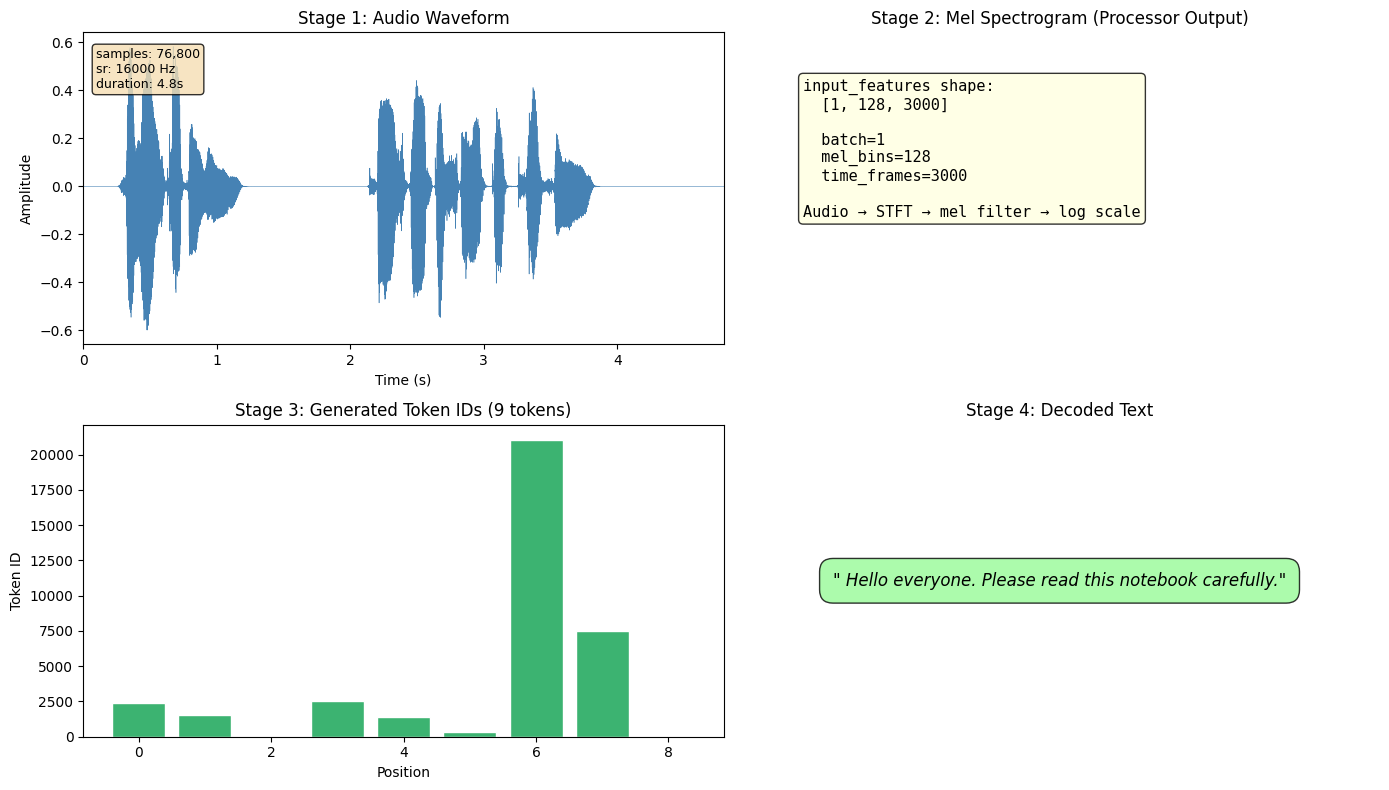

Audio: 76,800 samples @ 16000 Hz  |  Mel: [1, 128, 3000]  |  Tokens: 9  |  Text: " Hello everyone. Please read this notebook carefully...."


In [12]:
# Recompute the main intermediate objects so the visualization is self-contained.
sample = load_sample_audio()
audio_array = sample["audio"]["array"].astype(np.float32)
audio_sr = sample["audio"]["sampling_rate"]
inputs = processor(
    audio_array, sampling_rate=audio_sr,
    return_tensors="pt", return_attention_mask=True,
).to(device, dtype=torch_dtype)
pred_ids = model.generate(**inputs, max_new_tokens=256, num_beams=1, do_sample=False)
transcription = processor.batch_decode(pred_ids, skip_special_tokens=True)[0]

# The plot function needs the mel shape, generated token IDs, and final text.
mel_shape = tuple(inputs["input_features"].shape)

# Move token IDs back to CPU before plotting so matplotlib/numpy can read them.
plot_pipeline_flow(audio_array, audio_sr, mel_shape, pred_ids.cpu(), transcription)
plt.show()

# Print the same key measurements in text form for quick verification.
print(f"Audio: {len(audio_array):,} samples @ {audio_sr} Hz  |  "
      f"Mel: {list(mel_shape)}  |  "
      f"Tokens: {pred_ids.shape[-1]}  |  "
      f"Text: \"{transcription[:80]}...\"")

## 12. Flow Summary

```
Audio file (WAV / MP3 / etc.)
    ↓  soundfile.read() or datasets
1-D float32 numpy array, 16 kHz
    ↓  processor(audio, sampling_rate=16000)
Mel spectrogram tensor [1, 128, 3000]
    ↓  .to(device, dtype)
GPU/CPU tensor
    ↓  model.generate(max_new_tokens=256, do_sample=False)
Generated token IDs
    ↓  processor.batch_decode(skip_special_tokens=True)
Transcription text
```

For long recordings, the high-level pipeline manages repeated 30-second windows. With `chunk_length_s=30`, it uses chunked long-form transcription: split the audio into overlapping chunks, transcribe the chunks, and stitch the text back together.

### Key Point

**Whisper converts audio to text in four stages: waveform → mel spectrogram (processor), mel → token IDs (encoder-decoder with greedy decoding), token IDs → text (tokenizer).** The `pipeline` API wraps all stages into a single call and adds practical features such as timestamps, batching, language/task control, and chunked long-form transcription. The model is loaded once and reused. Greedy decoding (`do_sample=False`) ensures deterministic, reproducible output.

## Conclusion

### What You Learned

In this tutorial, you used the real **Whisper large-v3-turbo** model to transcribe audio, walking through every stage of the inference pipeline.

**Key concepts covered:**

1. **Model Architecture**
   - Transformer encoder-decoder (Seq2Seq): encoder processes mel spectrogram, decoder generates text tokens
   - Large-v3-turbo: pruned decoder (32 → 4 layers) for ~3× faster inference with minimal accuracy loss
   - Three components: model (neural network), processor (feature extraction), tokenizer (text ↔ token IDs)

2. **Audio Feature Extraction**
   - Audio must be mono, 16 kHz, float32
   - Processor computes a mel spectrogram: `[1, 128, 3000]` (128 frequency bins × 3000 time frames)
   - Audio is padded/truncated to 30-second windows

3. **Token Generation**
   - Greedy decoding (`do_sample=False`, `num_beams=1`) — deterministic, reproducible
   - `max_new_tokens=256` limits output length for this short demo
   - Special tokens (`<|startoftranscript|>`, `<|en|>`, `<|transcribe|>`) control language and task

4. **Token Decoding**
   - `processor.batch_decode(skip_special_tokens=True)` gives clean text
   - Without `skip_special_tokens`, you can inspect Whisper's control sequence

5. **Pipeline API**
   - `pipeline("automatic-speech-recognition", model=...)` wraps all stages
   - Supports language specification, timestamps, translation, batching, and chunked long-form transcription

### Next Steps

You can now:
- Use `Sample_Audio.mp3` as the single input audio file for this notebook
- Produce one transcription with the high-level pipeline cell
- Get sentence or word-level timestamps with `return_timestamps=True`
- Translate speech to English with `generate_kwargs={"task": "translate"}`
- Evaluate transcription quality using Word Error Rate (WER)
- Fine-tune Whisper on domain-specific data for better accuracy